# Third Toy Example: Single-Step Contrast under a Bimodal Density

We use a 1D input $x\in[-5,5]$ and a simple probabilistic process with a bimodal density. Specifically, we use a latent Bernoulli switch with Gaussian noise.
The true latent function is $f(x) = \sin(x)$.

The generative process for $y$ given $x$ is:
$$
z \sim \text{Bernoulli}(0.3), \qquad
y = 2z + f(x) + \epsilon,\qquad
\epsilon \sim \mathcal N(0,\sigma^2).
$$

So the likelihood of $y$ given the latent function $f(x)$ is a weighted mixture of two Gaussian level sets.

We contrast two *single-step* acquisition rules approximating the actual data distribution by using a **standard Gaussian Process with a unimodal Gaussian likelihood**, which means the models are completely agnostic to the fact that the data comes from a bimodal generative process.

1. High prior mean greedy: maximize the posterior predictive mean under a GP prior with mean $m(x)=3$. 
2. Zero prior mean UCB: maximize $\mu(x)+\beta\,\sigma(x)$ using an exact zero-mean GP posterior.

No sequential multi-round acquisition is run; we only compare one selected point per method.

In [160]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

x_min, x_max = -2.5, 2.5
x_min, x_max = -5.0, 5.0
x_grid = np.linspace(x_min, x_max, 400)

sigma_noise = 0.3
ell = 1  # GP lengthscale
# Decrease GP variance (e.g. from 1.0 to 0.2) to strictly enforce the prior mean
var_gp = 0.1
mu_high = 3.0
beta = 2.0

In [161]:
def rbf_kernel(X1, X2, l=ell, var=var_gp):
    sqdist = np.subtract.outer(X1, X2)**2
    return var * np.exp(-0.5 * sqdist / l**2)

def true_function(x):
    return np.sin(x)

def gp_predictive_exact(X_train, y_train, X_test, prior_mean_val=0.0):
    K = rbf_kernel(X_train, X_train)
    n = len(X_train)
    # Standard Gaussian likelihood implies Gaussian noise added to diagonal
    K_noise = K + (sigma_noise**2) * np.eye(n)

    L = np.linalg.cholesky(K_noise)
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y_train - prior_mean_val))

    K_s = rbf_kernel(X_train, X_test)
    f_mean = prior_mean_val + K_s.T @ alpha

    v = np.linalg.solve(L, K_s)
    f_var = var_gp - np.sum(v**2, axis=0)

    return f_mean, np.maximum(f_var, 0.0)

In [162]:
# Manually chosen observations highlighting the differences between the strategies
# We draw more points so the posterior and acquisition functions are better resolved.
num_points = 40
rng = np.random.default_rng(45)
X_obs = np.linspace(x_min + 0.2, x_max - 0.2, num_points)
z_obs = rng.binomial(1, 0.3, size=X_obs.shape[0])
y_obs = 2 * z_obs + true_function(X_obs) + rng.normal(0, sigma_noise, size=X_obs.shape[0])

# Reuse the same sampled points for both models.

# 1. High prior mean MAP-greedy
mean_high, var_high = gp_predictive_exact(X_obs, y_obs, x_grid, prior_mean_val=mu_high)
acq_high = mean_high
x_star_high = float(x_grid[np.argmax(acq_high)])

# 2. Zero prior mean UCB
mean_zero, var_zero = gp_predictive_exact(X_obs, y_obs, x_grid, prior_mean_val=0.0)
acq_zero_ucb = mean_zero + beta * np.sqrt(var_zero)
x_star_ucb = float(x_grid[np.argmax(acq_zero_ucb)])

print({
    "high_prior_greedy_x_star": round(x_star_high, 3),
    "zero_prior_ucb_exact_x_star": round(x_star_ucb, 3)
})

{'high_prior_greedy_x_star': -5.0, 'zero_prior_ucb_exact_x_star': -4.248}


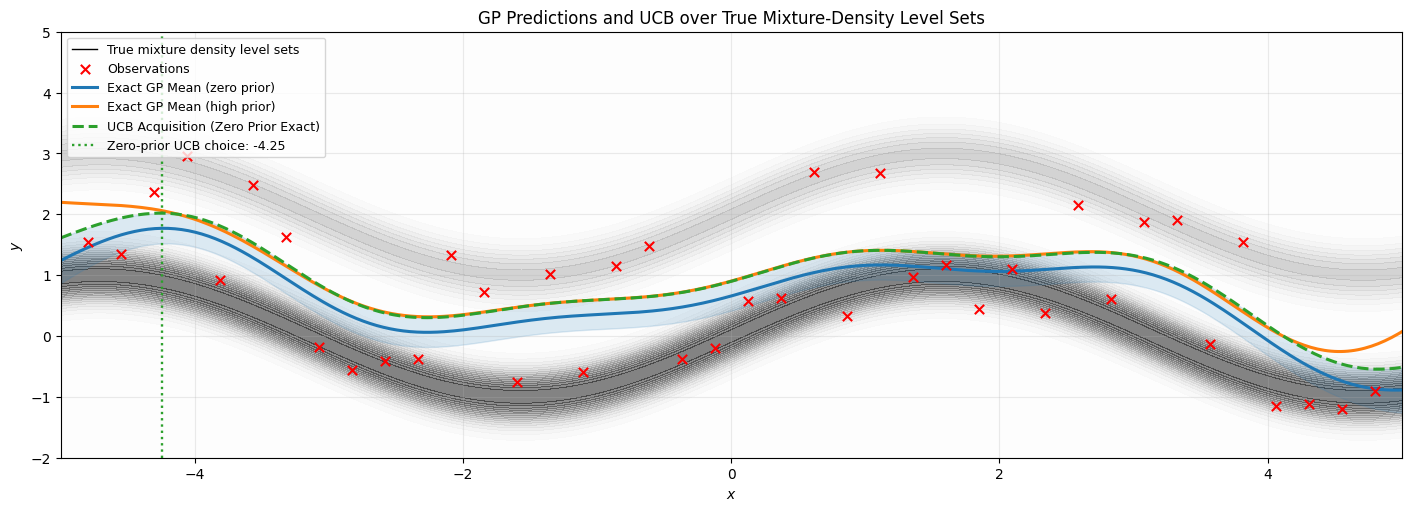

In [163]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(1, 1, figsize=(14, 5), constrained_layout=True)

# True components
y_true_low = true_function(x_grid)
y_true_high = 2.0 + true_function(x_grid)

# Plot confidence sets of the actual mixture density.
w_low = 0.7
y_grid = np.linspace(-2.0, 5.0, 320)
X_mesh, Y_mesh = np.meshgrid(x_grid, y_grid)

f_mesh = true_function(X_mesh)
norm_const = 1.0 / (np.sqrt(2.0 * np.pi) * sigma_noise)
pdf_low = norm_const * np.exp(-0.5 * ((Y_mesh - f_mesh) / sigma_noise) ** 2)
pdf_high = norm_const * np.exp(-0.5 * ((Y_mesh - (2.0 + f_mesh)) / sigma_noise) ** 2)
density_mix = w_low * pdf_low + (1.0 - w_low) * pdf_high

fill_levels = np.linspace(np.min(density_mix), np.max(density_mix), 18)
line_levels = np.unique(np.quantile(density_mix, [0.60, 0.75, 0.86, 0.93, 0.97, 0.99]))
if line_levels.size < 2:
    line_levels = np.linspace(np.min(density_mix), np.max(density_mix), 7)[1:-1]

ax.contourf(x_grid, y_grid, density_mix, levels=fill_levels, cmap="Greys", alpha=0.5)
# ax.contour(x_grid, y_grid, density_mix, levels=line_levels, colors="black", linewidths=0.8, alpha=0.45)
density_proxy = Line2D([0], [0], color="black", lw=1.0, label="True mixture density level sets")

ax.scatter(X_obs, y_obs, color="red", s=45, marker="x", label="Observations", zorder=5)

ax.plot(x_grid, mean_zero, color="tab:blue", lw=2.2, label="Exact GP Mean (zero prior)")
ax.fill_between(x_grid, mean_zero - 2*np.sqrt(var_zero), mean_zero + 2*np.sqrt(var_zero), color="tab:blue", alpha=0.15)

ax.plot(x_grid, mean_high, color="tab:orange", lw=2.2, label="Exact GP Mean (high prior)")

ax.plot(x_grid, acq_zero_ucb, color="tab:green", lw=2.2, ls="--", label=r"UCB Acquisition (Zero Prior Exact)")
ax.axvline(x_star_ucb, color="tab:green", ls=":", lw=1.7, label=f"Zero-prior UCB choice: {x_star_ucb:.2f}")

ax.set_title("GP Predictions and UCB over True Mixture-Density Level Sets")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.grid(alpha=0.25)
handles, labels = ax.get_legend_handles_labels()
legend_labels = [str(density_proxy.get_label())] + [str(lbl) for lbl in labels]
ax.legend([density_proxy] + handles, legend_labels, loc="upper left", fontsize=9)

plt.show()

### Interpretation

Because the data is generated from an asymmetric Bernoulli switch ($z\sim\text{Bernoulli}(0.7)$ for the lower level, $0.3$ for the upper level), the actual distribution of $y$ conditioned on $x$ is bimodal with two parallel modes near $f(x)$ and $2 + f(x)$.

When we fit an **exact Gaussian Process** with a standard Gaussian likelihood, the model assumes that data is unimodal and homoscedastic. This completely misspecifies the true data generative process.

A zero-prior GP struggles to pick a mode when observations vary between the two shifted levels. This results in a mean that compromises between the modes, leading to high predictive variance and triggering exploratory UCB behavior.

A high-prior GP imposes a strong prior belief favoring the shifted positive level. The exact GP estimate is pulled up closer to that sparsely populated upper curve, allowing greedy exploitation in those regions rather than collapsing to the denser bottom curve or compromising evenly across the multimodality.